# ⚡ ChargePoint — EV Charging Station Anomaly Detection
**ChargePoint AI/ML Intern Take-Home Assignment**

This notebook walks through the full pipeline:
1. Setup & data loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training (Isolation Forest + Hard Rules)
5. Evaluation & Inspection

## 0. Setup

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All imports OK')

All imports OK


In [2]:
DATA_PATH = "/content/charging_logs.csv"

## 1. Load & Preprocess

In [5]:
def load_and_preprocess(path: str) -> pd.DataFrame:
    """
    Load CSV, parse timestamps, sort, and add derived columns:
    - power_calc_kw   : V * I / 1000  (sanity check vs reported power)
    - power_discrepancy : |reported - calculated| power
    - has_error       : 1 if error_code != 0
    - energy_rate     : kWh / duration_sec  (catches meter anomalies)
    """
    df = pd.read_csv(path, parse_dates=['timestamp'])
    # print(f'Shape: {df.shape}')
    df = df.sort_values(['station_id', 'timestamp']).reset_index(drop=True)

    df['power_calc_kw']     = (df['voltage'] * df['current']) / 1000.0
    df['power_discrepancy'] = (df['power_kw'] - df['power_calc_kw']).abs()
    df['has_error']         = (df['error_code'] != 0).astype(int)
    df['energy_rate']       = df['energy_kwh'] / df['duration_sec'].clip(lower=1)

    return df

df = load_and_preprocess(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (199566, 15)


,station_id,timestamp,session_id,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,message,power_calc_kw,power_discrepancy,has_error,energy_rate
0,STATION_0,2024-01-15 01:00:06,a73a9733a702,229.3500,31.8100,7.2690,42.2300,19,0.0384,0,OK,7.2956,0.0266,0,0.0020
1,STATION_0,2024-01-15 01:00:07,a73a9733a702,225.3800,34.6700,7.8150,45.2900,38,0.0825,0,OK,7.8139,0.0011,0,0.0022
2,STATION_0,2024-01-15 01:00:12,a73a9733a702,228.6000,32.4600,7.4210,42.3900,42,0.0866,0,OK,7.4204,0.0006,0,0.0021
3,STATION_0,2024-01-15 01:00:16,a73a9733a702,233.8700,35.9100,8.4170,43.2300,28,0.0655,0,OK,8.3983,0.0187,0,0.0023
4,STATION_0,2024-01-15 01:00:18,a73a9733a702,231.0700,32.4400,7.3850,45.8700,24,0.0492,0,OK,7.4959,0.1109,0,0.0021


In [6]:
print('Dtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDescribe:')
df.describe()

Dtypes:
station_id                   object
timestamp            datetime64[ns]
session_id                   object
voltage                     float64
current                     float64
power_kw                    float64
temperature_c               float64
duration_sec                  int64
energy_kwh                  float64
error_code                    int64
message                      object
power_calc_kw               float64
power_discrepancy           float64
has_error                     int64
energy_rate                 float64
dtype: object

Missing values:
station_id           0
timestamp            0
session_id           0
voltage              0
current              0
power_kw             0
temperature_c        0
duration_sec         0
energy_kwh           0
error_code           0
message              0
power_calc_kw        0
power_discrepancy    0
has_error            0
energy_rate          0
dtype: int64

Describe:


,timestamp,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,power_calc_kw,power_discrepancy,has_error,energy_rate
count,199566,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000
mean,2024-07-03 17:29:47.673416192,228.6736,30.1559,6.8574,45.0982,30.5061,0.0599,1.4070,6.8943,0.1976,0.0056,0.0020
min,2024-01-01 00:05:42,88.7100,0.0000,-8.9240,-8.4500,1.0000,0.0013,0.0000,0.0000,0.0000,0.0000,0.0012
25%,2024-04-04 23:46:22.500000,224.2100,28.2300,6.4390,41.7500,16.0000,0.0298,0.0000,6.4349,0.0174,0.0000,0.0018
50%,2024-07-04 02:03:58,227.9500,30.4200,6.9360,45.8100,30.0000,0.0584,0.0000,6.9355,0.0377,0.0000,0.0019
75%,2024-10-02 19:09:31.750000128,232.2400,32.4300,7.4160,48.9200,46.0000,0.0872,0.0000,7.4198,0.0681,0.0000,0.0021
max,2024-12-30 23:40:38,390.9600,41.7000,9.6100,93.9800,60.0000,0.6979,404.0000,13.7661,17.8171,1.0000,0.0138
std,NaN,12.9863,3.7386,1.2396,6.0333,17.3340,0.0396,20.6117,0.9310,1.1986,0.0743,0.0006


In [27]:
df[df['error_code'] != 0].describe()

,timestamp,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,power_calc_kw,power_discrepancy,has_error,energy_rate,hour,dayofweek,is_weekend,voltage_roll_mean,voltage_roll_std,voltage_delta,current_roll_mean,current_roll_std,current_delta,power_kw_roll_mean,power_kw_roll_std,power_kw_delta,temperature_c_roll_mean,temperature_c_roll_std,temperature_c_delta,session_error_rate,session_event_count,session_total_energy,session_avg_power,session_max_temp,voltage_mean,voltage_std,current_mean,current_std,power_kw_mean,power_kw_std,temperature_c_mean,temperature_c_std,voltage_zscore,current_zscore,power_kw_zscore,temperature_c_zscore,is_anomaly,anomaly_score
count,1109,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000,1109.0000
mean,2024-07-03 15:28:07.704237824,229.2167,30.2440,6.9329,45.2938,30.2714,0.0584,253.1830,6.9303,0.0468,1.0000,0.0019,11.8025,3.0415,0.2949,229.0528,4.7092,0.1639,30.0300,2.1792,0.2140,6.8264,0.6210,0.1065,45.3158,2.4289,-0.0221,0.0257,55.7574,3.3439,6.8444,56.6128,229.1038,11.5643,30.0414,3.0430,6.8444,1.1292,45.2662,3.8516,0.0103,0.0664,0.0783,0.0073,1.0000,-0.4805
min,2024-01-01 14:37:20,211.3100,19.6700,4.6050,30.0300,1.0000,0.0017,101.0000,4.8050,0.0001,1.0000,0.0013,0.0000,0.0000,0.0000,198.6080,0.5755,-27.8300,19.6180,0.2934,-5.7720,3.2596,0.0534,-1.4376,31.2400,0.3065,-10.7600,0.0125,20.0000,0.9574,5.3715,37.8900,219.9721,10.5175,26.2224,2.7513,5.9089,0.9973,35.5414,3.5851,-0.7850,-2.4540,-1.6197,-1.7732,1.0000,-0.5819
25%,2024-04-02 18:43:09,224.8600,28.3000,6.4390,42.1600,15.0000,0.0283,202.0000,6.4417,0.0177,1.0000,0.0018,6.0000,1.0000,0.0000,224.9260,2.1294,-1.6700,27.9440,1.3857,-1.1280,6.4066,0.3295,-0.2620,42.2400,1.4503,-1.2420,0.0154,43.0000,2.5222,6.3758,48.3700,225.4997,11.1932,27.6266,2.9170,6.3439,1.0770,42.6681,3.7543,-0.1590,-0.3461,-0.1717,-0.3402,1.0000,-0.4989
50%,2024-07-08 05:09:17,228.5400,30.2900,6.9180,45.8200,30.0000,0.0593,303.0000,6.9279,0.0369,1.0000,0.0019,12.0000,3.0000,0.0000,227.9920,2.8051,0.1740,30.3500,1.8242,0.1060,6.9040,0.4331,0.0392,45.9440,1.8756,-0.0140,0.0222,58.0000,3.4051,6.8809,52.4900,228.0516,11.5596,30.6798,3.0296,6.8969,1.0858,46.5471,3.8038,0.0104,0.0851,0.0951,0.0066,1.0000,-0.4751
75%,2024-10-01 21:48:11,232.9400,32.2800,7.4210,49.0100,46.0000,0.0874,303.0000,7.4109,0.0668,1.0000,0.0021,18.0000,5.0000,1.0000,232.9380,3.6143,1.9860,32.1000,2.3642,1.3580,7.3452,0.5608,0.3128,48.9140,2.4145,1.2280,0.0323,70.0000,4.2069,7.2493,63.4700,233.3039,12.1560,31.3145,3.1373,7.3262,1.2182,49.0402,3.9533,0.1810,0.5080,0.3532,0.3606,1.0000,-0.4596
max,2024-12-30 18:45:32,254.1400,38.7600,8.9180,55.7300,60.0000,0.1323,404.0000,8.9152,0.2168,1.0000,0.0025,23.0000,6.0000,1.0000,272.7020,58.6786,25.4080,35.9840,15.5848,9.6720,8.4010,7.3936,3.6064,59.1280,19.6000,8.7420,0.0909,80.0000,6.0632,8.0391,90.9200,246.3550,12.4163,33.4889,3.4688,7.8092,1.2667,51.6878,4.1816,0.8467,2.0127,1.4340,2.1762,1.0000,-0.4190
std,NaN,6.7257,2.9091,0.6822,4.9118,17.5529,0.0344,112.7664,0.6772,0.0393,0.0000,0.0002,6.7577,1.9928,0.4562,7.7965,9.1203,5.0379,2.6246,1.9993,2.0326,0.7571,1.0273,0.6441,4.7847,2.6690,2.1605,0.0128,16.5875,1.0657,0.5534,12.6347,6.1406,0.6217,2.2321,0.1683,0.5250,0.0819,4.5667,0.1744,0.2588,0.6531,0.4163,0.5203,0.0000,0.0283


## 2. Exploratory Data Analysis (EDA)

### 2.1 Feature Distributions

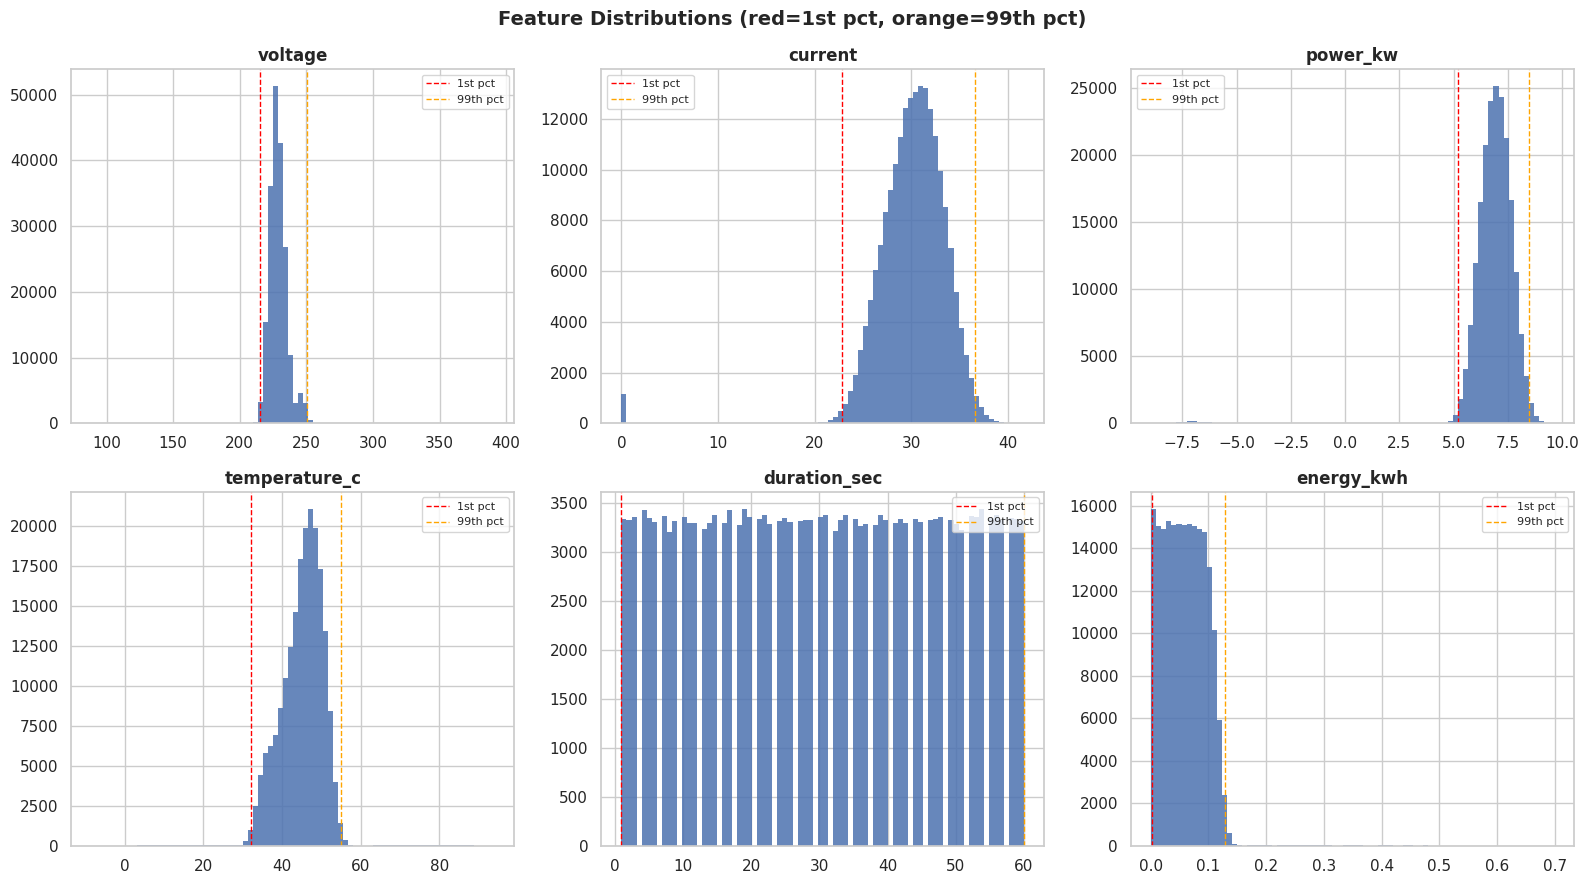

In [7]:
numeric_cols = ['voltage', 'current', 'power_kw', 'temperature_c', 'duration_sec', 'energy_kwh']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col].dropna(), bins=80, color='#4C72B0', edgecolor='none', alpha=0.85)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    # Highlight extreme values
    q1, q99 = df[col].quantile([0.01, 0.99])
    ax.axvline(q1,  color='red',    linestyle='--', linewidth=1, label='1st pct')
    ax.axvline(q99, color='orange', linestyle='--', linewidth=1, label='99th pct')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions (red=1st pct, orange=99th pct)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Correlation Heatmap

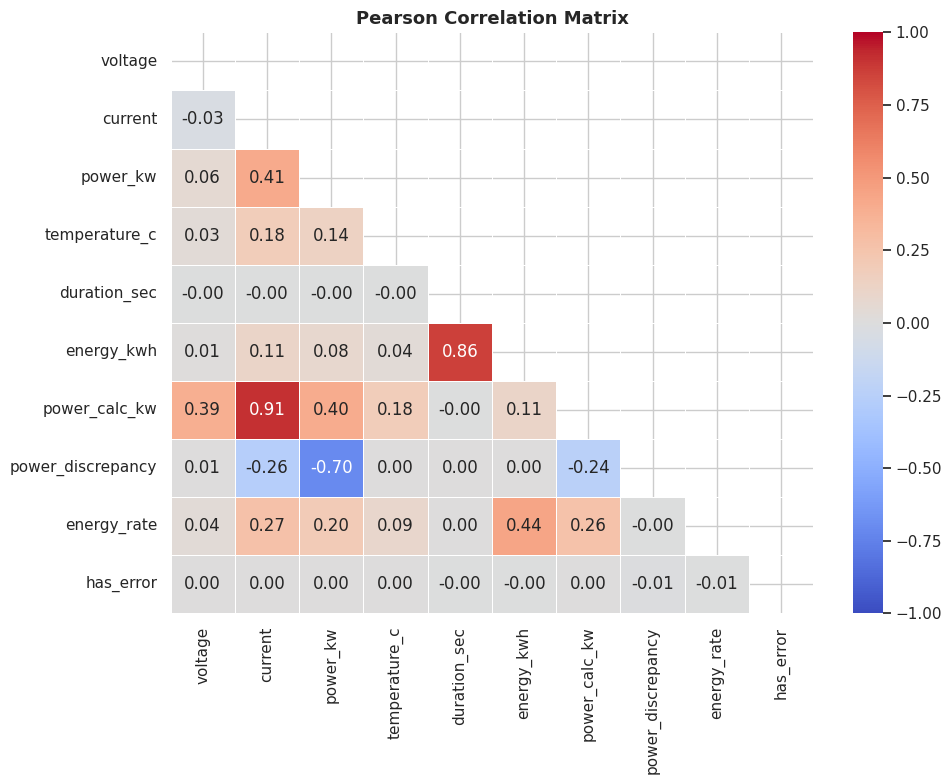

In [8]:
corr_cols = numeric_cols + ['power_calc_kw', 'power_discrepancy', 'energy_rate', 'has_error']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, mask=mask)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Temporal Patterns

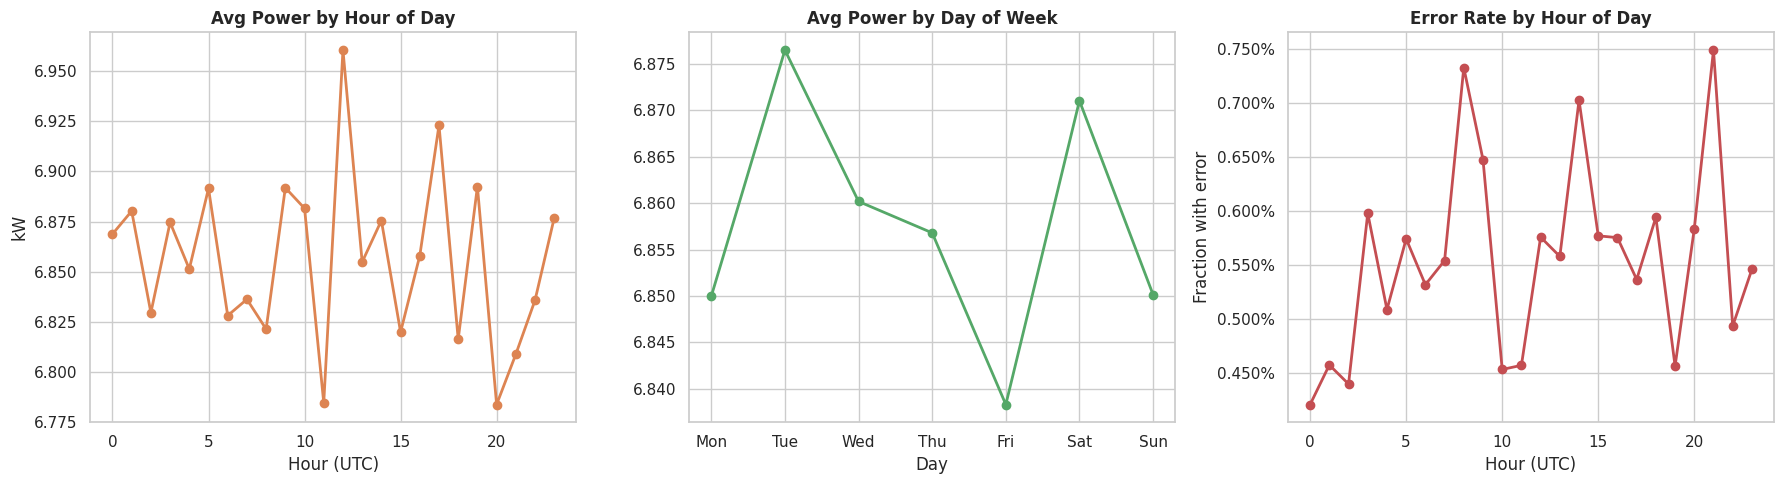

In [9]:
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['is_weekend']= (df['dayofweek'] >= 5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Power by hour
df.groupby('hour')['power_kw'].mean().plot(ax=axes[0], color='#DD8452', marker='o', linewidth=2)
axes[0].set_title('Avg Power by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (UTC)'); axes[0].set_ylabel('kW')

# Power by day of week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df.groupby('dayofweek')['power_kw'].mean().rename(
    index=dict(enumerate(day_names))).plot(
    ax=axes[1], color='#55A868', marker='o', linewidth=2)
axes[1].set_title('Avg Power by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')

# Error rate by hour
df.groupby('hour')['has_error'].mean().plot(ax=axes[2], color='#C44E52', marker='o', linewidth=2)
axes[2].set_title('Error Rate by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour (UTC)'); axes[2].set_ylabel('Fraction with error')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

### 2.4 Error Code Analysis

Total events with errors: 1,109 (0.56%)
Unique error codes: 4

Top error codes:
error_code
303    286
101    276
404    276
202    271
Name: count, dtype: int64


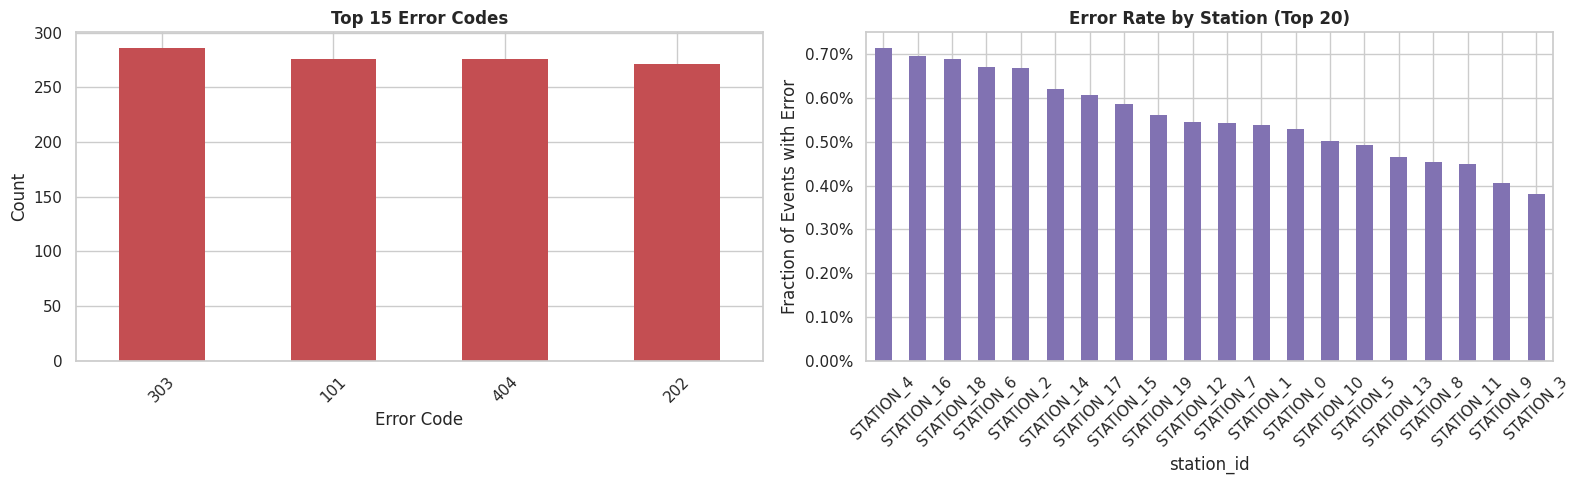

In [10]:
errors = df[df['error_code'] != 0]
print(f'Total events with errors: {len(errors):,} ({len(errors)/len(df):.2%})')
print(f'Unique error codes: {errors["error_code"].nunique()}')
print('\nTop error codes:')
print(errors['error_code'].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

errors['error_code'].value_counts().head(15).plot(
    kind='bar', ax=axes[0], color='#C44E52', edgecolor='none')
axes[0].set_title('Top 15 Error Codes', fontweight='bold')
axes[0].set_xlabel('Error Code'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Error rate per station
station_err = df.groupby('station_id')['has_error'].mean().sort_values(ascending=False).head(20)
station_err.plot(kind='bar', ax=axes[1], color='#8172B2', edgecolor='none')
axes[1].set_title('Error Rate by Station (Top 20)', fontweight='bold')
axes[1].set_ylabel('Fraction of Events with Error')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.5 Power vs Temperature (colored by fault)

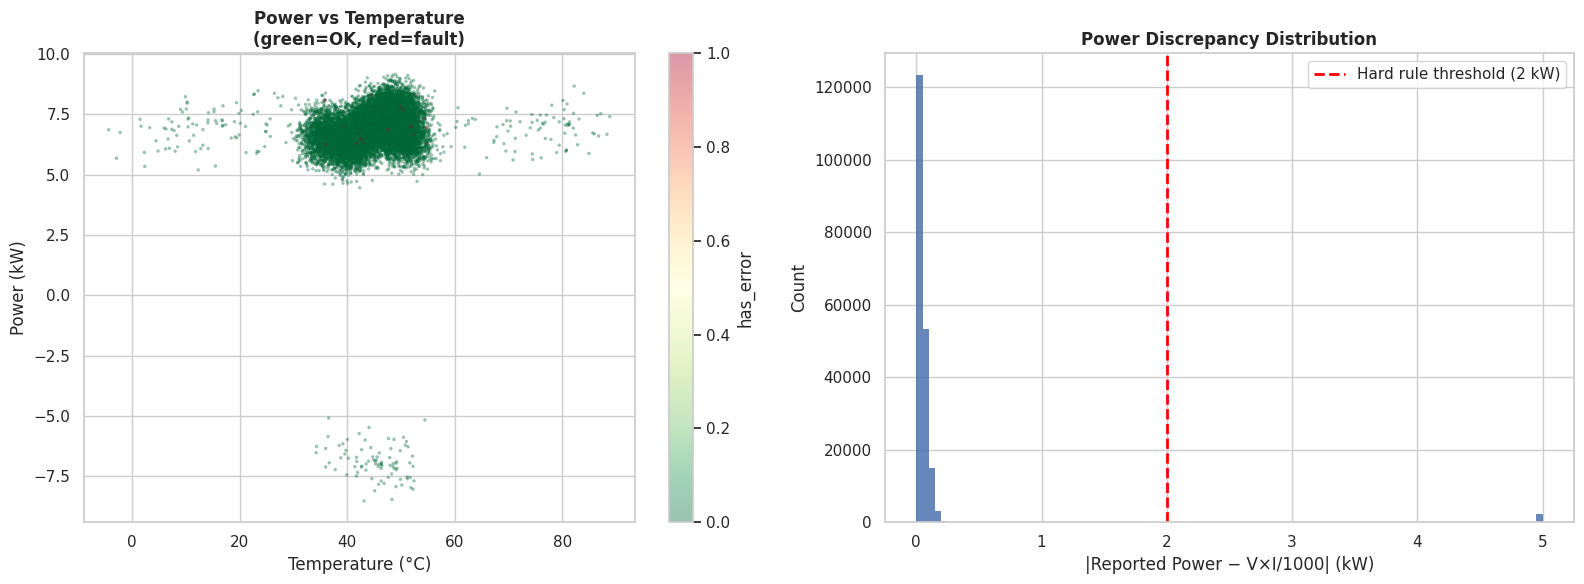

Events with power discrepancy > 2 kW: 2.24%


In [11]:
sample = df.sample(min(15_000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: power vs temp, colored by error
sc = axes[0].scatter(
    sample['temperature_c'], sample['power_kw'],
    c=sample['has_error'], cmap='RdYlGn_r',
    alpha=0.4, s=6, linewidths=0
)
plt.colorbar(sc, ax=axes[0], label='has_error')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Power (kW)')
axes[0].set_title('Power vs Temperature\n(green=OK, red=fault)', fontweight='bold')

# Power discrepancy distribution
axes[1].hist(df['power_discrepancy'].clip(0, 5), bins=100,
             color='#4C72B0', edgecolor='none', alpha=0.85)
axes[1].axvline(2.0, color='red', linestyle='--', linewidth=2, label='Hard rule threshold (2 kW)')
axes[1].set_xlabel('|Reported Power − V×I/1000| (kW)')
axes[1].set_ylabel('Count')
axes[1].set_title('Power Discrepancy Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

pct = (df['power_discrepancy'] > 2.0).mean()
print(f'Events with power discrepancy > 2 kW: {pct:.2%}')

### 2.6 Outlier Summary

In [12]:
print('=== OUTLIER SUMMARY ===')
print(f"Voltage < 150 V          : {(df['voltage'] < 150).sum():>8,}")
print(f"Voltage > 300 V          : {(df['voltage'] > 300).sum():>8,}")
print(f"Power < 0 kW             : {(df['power_kw'] < 0).sum():>8,}")
print(f"Temperature < 0°C        : {(df['temperature_c'] < 0).sum():>8,}")
print(f"Temperature > 80°C       : {(df['temperature_c'] > 80).sum():>8,}")
print(f"Non-zero error code      : {(df['error_code'] != 0).sum():>8,}")
print(f"Power discrepancy > 2 kW : {(df['power_discrepancy'] > 2).sum():>8,}")

=== OUTLIER SUMMARY ===
Voltage < 150 V          :      953
Voltage > 300 V          :    1,072
Power < 0 kW             :    1,103
Temperature < 0°C        :       31
Temperature > 80°C       :      355
Non-zero error code      :    1,109
Power discrepancy > 2 kW :    4,478


## 3. Feature Engineering

In [13]:
def add_rolling_features(df: pd.DataFrame, window: int = 5) -> pd.DataFrame:
    """
    Per-station rolling mean, std, and delta over the last `window` events.
    Captures sudden local deviations that global statistics would miss.
    E.g. a 250V reading is abnormal if the station usually runs at 220V.
    """
    df = df.copy()
    for col in ['voltage', 'current', 'power_kw', 'temperature_c']:
        grp = df.groupby('station_id')[col]
        df[f'{col}_roll_mean'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f'{col}_roll_std'] = grp.transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )
        df[f'{col}_delta'] = df[col] - df[f'{col}_roll_mean']
    return df


def add_session_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Session-level aggregates: error rate, total energy, event count, etc.
    A session with 40% error events is a strong anomaly signal even if
    each individual event looks only mildly unusual.
    """
    sess = df.groupby('session_id').agg(
        session_error_rate  = ('has_error', 'mean'),
        session_event_count = ('session_id', 'count'),
        session_total_energy= ('energy_kwh', 'sum'),
        session_avg_power   = ('power_kw', 'mean'),
        session_max_temp    = ('temperature_c', 'max'),
    ).reset_index()
    return df.merge(sess, on='session_id', how='left')


def add_station_baseline_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Global per-station mean/std → z-scores.
    Z-score > 3.5 on voltage, current, or temperature triggers the hard rule.
    """
    baseline_cols = ['voltage', 'current', 'power_kw', 'temperature_c']
    station_stats = df.groupby('station_id')[baseline_cols].agg(['mean', 'std'])
    station_stats.columns = ['_'.join(c) for c in station_stats.columns]
    station_stats = station_stats.reset_index()

    df = df.merge(station_stats, on='station_id', how='left')
    for col in baseline_cols:
        std = df[f'{col}_std'].fillna(1e-6).replace(0, 1e-6)
        df[f'{col}_zscore'] = (df[col] - df[f'{col}_mean'].fillna(0)) / std
    return df


print('Feature functions defined')

Feature functions defined


In [14]:
# Apply all feature engineering
df = add_rolling_features(df)
df = add_session_features(df)
df = add_station_baseline_features(df)

print(f'Enriched shape: {df.shape}')
print('New columns:', [c for c in df.columns if any(
    c.startswith(p) for p in ['session_','voltage_z','current_z','power_kw_z',
                               'temperature_c_z','voltage_delta','power_disc'])])

Enriched shape: (199566, 47)
New columns: ['session_id', 'power_discrepancy', 'voltage_delta', 'session_error_rate', 'session_event_count', 'session_total_energy', 'session_avg_power', 'session_max_temp', 'voltage_zscore', 'current_zscore', 'power_kw_zscore', 'temperature_c_zscore']


In [15]:
# Build the feature matrix (select only model input columns)
FEATURE_COLS = [
    # Raw signals
    'voltage', 'current', 'power_kw', 'temperature_c',
    'duration_sec', 'energy_kwh', 'error_code', 'has_error',
    # Derived
    'power_discrepancy', 'energy_rate', 'power_calc_kw',
    # Temporal
    'hour', 'dayofweek', 'is_weekend',
    # Rolling deltas
    'voltage_delta', 'current_delta', 'power_kw_delta', 'temperature_c_delta',
    'voltage_roll_std', 'current_roll_std', 'power_kw_roll_std', 'temperature_c_roll_std',
    # Session
    'session_error_rate', 'session_event_count', 'session_total_energy',
    'session_avg_power', 'session_max_temp',
    # Station z-scores
    'voltage_zscore', 'current_zscore', 'power_kw_zscore', 'temperature_c_zscore',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
print(f'Feature matrix: {X.shape}')
X.describe()

Feature matrix: (199566, 31)


,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,has_error,power_discrepancy,energy_rate,power_calc_kw,hour,dayofweek,is_weekend,voltage_delta,current_delta,power_kw_delta,temperature_c_delta,voltage_roll_std,current_roll_std,power_kw_roll_std,temperature_c_roll_std,session_error_rate,session_event_count,session_total_energy,session_avg_power,session_max_temp,voltage_zscore,current_zscore,power_kw_zscore,temperature_c_zscore
count,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000,199566.0000
mean,228.6736,30.1559,6.8574,45.0982,30.5061,0.0599,1.4070,0.0056,0.1976,0.0020,6.8943,11.4950,3.0029,0.2855,-0.0002,-0.0000,-0.0000,0.0000,5.2772,2.2170,0.5998,2.5431,0.0056,56.1558,3.3668,6.8574,56.8880,-0.0000,-0.0000,-0.0000,-0.0000
std,12.9863,3.7386,1.2396,6.0333,17.3340,0.0396,20.6117,0.0743,1.1986,0.0006,0.9310,6.9187,2.0038,0.4516,10.3792,2.7289,1.0129,3.4444,10.3321,2.0986,0.9609,2.8873,0.0106,16.5983,1.0718,0.5290,13.1358,1.0000,1.0000,1.0000,1.0000
min,88.7100,0.0000,-8.9240,-8.4500,1.0000,0.0013,0.0000,0.0000,0.0000,0.0012,0.0000,0.0000,0.0000,0.0000,-134.3580,-28.6120,-13.5986,-41.9160,0.0000,0.0000,0.0000,0.0000,0.0000,20.0000,0.7572,5.3715,37.7400,-13.4890,-10.5502,-14.6310,-11.6443
25%,224.2100,28.2300,6.4390,41.7500,16.0000,0.0298,0.0000,0.0000,0.0174,0.0018,6.4349,5.0000,1.0000,0.0000,-1.9480,-1.1920,-0.2820,-1.2900,2.1296,1.3977,0.3281,1.4204,0.0000,43.0000,2.5506,6.4148,48.2900,-0.1793,-0.3948,-0.2194,-0.3580
50%,227.9500,30.4200,6.9360,45.8100,30.0000,0.0584,0.0000,0.0000,0.0377,0.0019,6.9355,12.0000,3.0000,0.0000,0.0000,0.0460,0.0092,0.0000,2.8332,1.8518,0.4355,1.8859,0.0000,58.0000,3.4574,6.8960,52.3800,-0.0015,0.0546,0.0643,-0.0031
75%,232.2400,32.4300,7.4160,48.9200,46.0000,0.0872,0.0000,0.0000,0.0681,0.0021,7.4198,18.0000,5.0000,1.0000,1.9500,1.2940,0.3026,1.2960,3.6515,2.3723,0.5568,2.4314,0.0128,71.0000,4.2010,7.2479,65.8000,0.1763,0.4966,0.3470,0.3542
max,390.9600,41.7000,9.6100,93.9800,60.0000,0.6979,404.0000,1.0000,17.8171,0.0138,13.7661,23.0000,6.0000,1.0000,130.2820,14.6460,6.1880,39.1480,94.8466,18.5780,8.5342,27.8353,0.0909,80.0000,6.2337,8.0757,93.9800,13.2912,3.3558,2.1188,11.3716


## 4. Model Training

### 4.1 Hard Rules (zero false negatives for known faults)

In [16]:
ZSCORE_THRESHOLD   = 3.5
POWER_DISC_THRESH  = 2.0  # kW

def apply_hard_rules(df: pd.DataFrame) -> np.ndarray:
    """
    Returns a boolean array: True = anomaly by rule.

    Rules:
    1. Non-zero error code from charger firmware
    2. Negative power (physically impossible)
    3. Station z-score > 3.5 for voltage, current, or temperature
    4. Power discrepancy > 2 kW (reported vs V*I/1000)
    """
    flags = np.zeros(len(df), dtype=bool)

    flags |= df['has_error'].astype(bool).values             # Rule 1
    flags |= (df['power_kw'] < 0).values                     # Rule 2

    for col in ['voltage_zscore', 'current_zscore', 'temperature_c_zscore']:
        if col in df.columns:
            flags |= (df[col].abs() > ZSCORE_THRESHOLD).values   # Rule 3

    if 'power_discrepancy' in df.columns:
        flags |= (df['power_discrepancy'] > POWER_DISC_THRESH).values  # Rule 4

    return flags

rule_flags = apply_hard_rules(df)
print(f'Hard rules flag: {rule_flags.sum():,} events ({rule_flags.mean():.2%})')

Hard rules flag: 7,935 events (3.98%)


### 4.2 Isolation Forest

In [17]:
# Contamination = estimated fraction of anomalies.
# 3% is a reasonable default for synthetic EV fault injection datasets.
# Tune this up/down to adjust sensitivity.
CONTAMINATION = 0.03

model = Pipeline([
    ('scaler',  StandardScaler()),
    ('iforest', IsolationForest(
        n_estimators  = 200,
        contamination = CONTAMINATION,
        max_samples   = 'auto',
        random_state  = 42,
        n_jobs        = -1,
    ))
])

print('Training Isolation Forest...')
model.fit(X)
print('Done')

Training Isolation Forest...
Done


In [18]:
# Predict
raw_preds = model.predict(X)       # -1 = anomaly, +1 = normal
scores    = model.score_samples(X) # lower = more anomalous

model_flags = (raw_preds == -1)

# Final label = UNION of model flags and hard rule flags
is_anomaly = (model_flags | rule_flags).astype(int)

df['is_anomaly']    = is_anomaly
df['anomaly_score'] = scores

print(f'Model flags  : {model_flags.sum():,} ({model_flags.mean():.2%})')
print(f'Rule flags   : {rule_flags.sum():,}  ({rule_flags.mean():.2%})')
print(f'Combined     : {is_anomaly.sum():,} ({is_anomaly.mean():.2%})')

Model flags  : 5,987 (3.00%)
Rule flags   : 7,935  (3.98%)
Combined     : 8,552 (4.29%)


## 5. Evaluation & Inspection

### 5.1 Anomaly Score Distribution

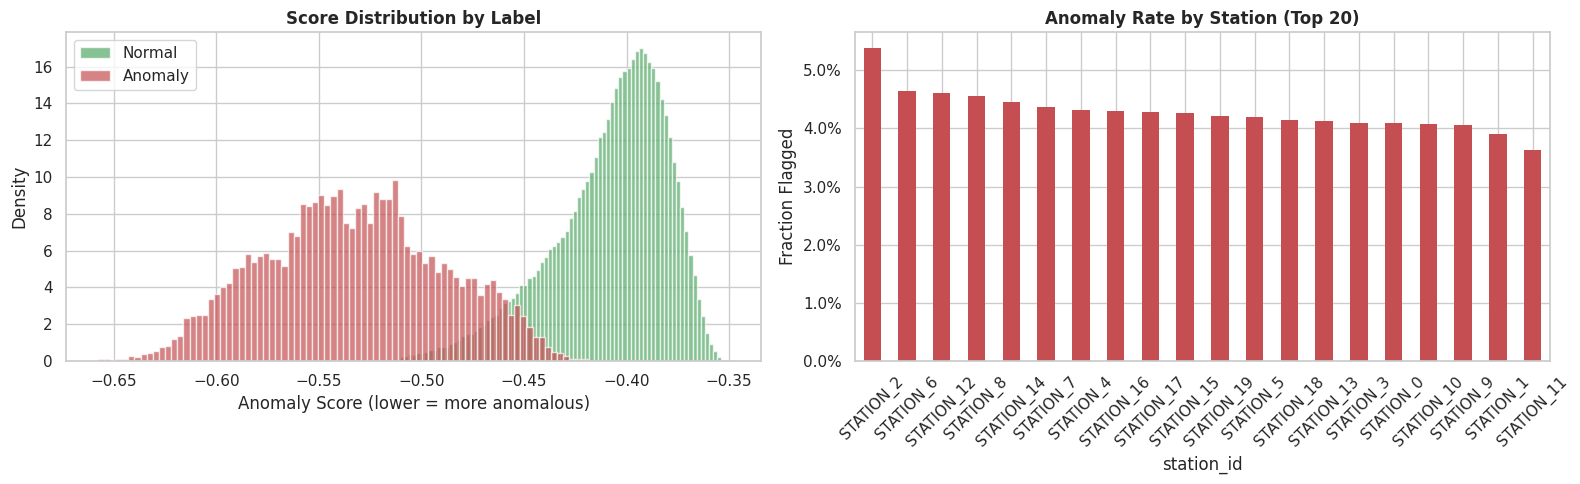

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score distribution split by label
normal_scores  = scores[is_anomaly == 0]
anomaly_scores = scores[is_anomaly == 1]

axes[0].hist(normal_scores,  bins=80, alpha=0.7, color='#55A868', label='Normal',   density=True)
axes[0].hist(anomaly_scores, bins=80, alpha=0.7, color='#C44E52', label='Anomaly',  density=True)
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by Label', fontweight='bold')
axes[0].legend()

# Anomaly rate by station
station_anomaly = df.groupby('station_id')['is_anomaly'].mean().sort_values(ascending=False).head(20)
station_anomaly.plot(kind='bar', ax=axes[1], color='#C44E52', edgecolor='none')
axes[1].set_title('Anomaly Rate by Station (Top 20)', fontweight='bold')
axes[1].set_ylabel('Fraction Flagged')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 5.2 Anomaly Rate by Hour & Contamination Sensitivity

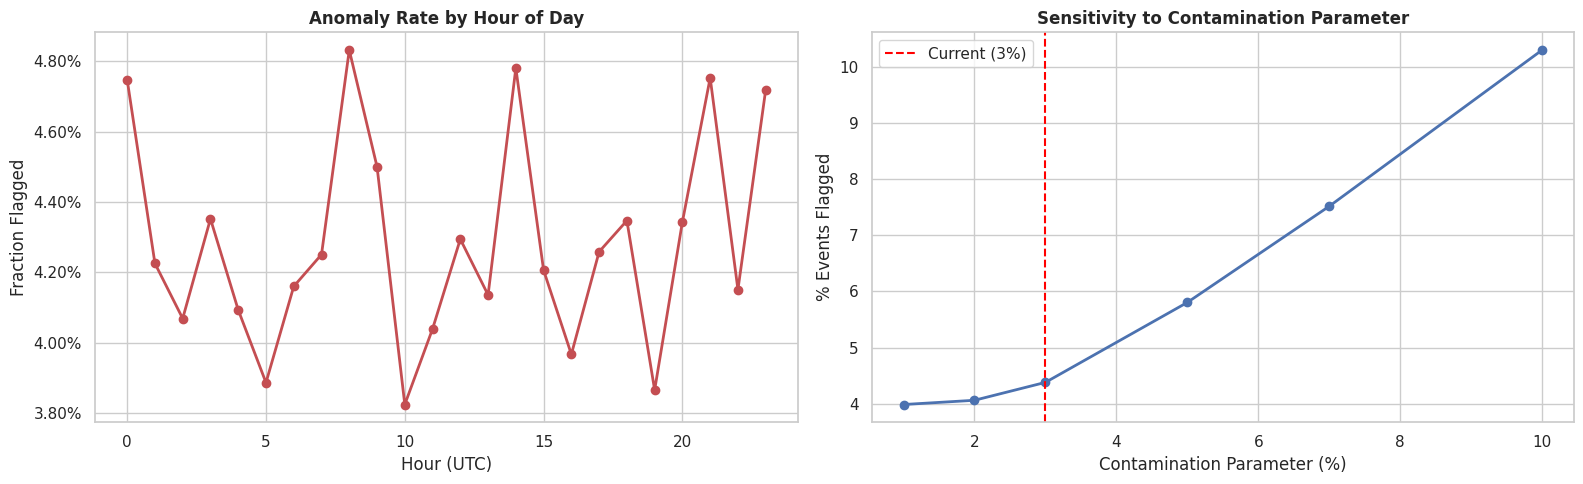

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Anomaly rate by hour
df.groupby('hour')['is_anomaly'].mean().plot(
    ax=axes[0], color='#C44E52', marker='o', linewidth=2)
axes[0].set_title('Anomaly Rate by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Fraction Flagged')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Sensitivity: how many events flagged at different contamination levels
contamination_vals = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10]
flagged_counts = []
for c in contamination_vals:
    m = Pipeline([
        ('scaler', StandardScaler()),
        ('iforest', IsolationForest(n_estimators=100, contamination=c, random_state=42, n_jobs=-1))
    ]).fit(X)
    preds = m.predict(X)
    combined = ((preds == -1) | rule_flags)
    flagged_counts.append(combined.mean() * 100)

axes[1].plot([c*100 for c in contamination_vals], flagged_counts,
             marker='o', color='#4C72B0', linewidth=2)
axes[1].set_xlabel('Contamination Parameter (%)')
axes[1].set_ylabel('% Events Flagged')
axes[1].set_title('Sensitivity to Contamination Parameter', fontweight='bold')
axes[1].axvline(CONTAMINATION*100, color='red', linestyle='--', label=f'Current ({CONTAMINATION*100:.0f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Top Anomalous Events

In [21]:
top_anomalies = (
    df[df['is_anomaly'] == 1]
    .sort_values('anomaly_score')  # most anomalous first
    [['station_id', 'timestamp', 'session_id',
      'voltage', 'current', 'power_kw', 'temperature_c',
      'error_code', 'message', 'anomaly_score']]
    .head(20)
)

print(f'Total anomalous events: {df["is_anomaly"].sum():,}')
print('\nTop 20 most anomalous events:')
top_anomalies

Total anomalous events: 8,552

Top 20 most anomalous events:


,station_id,timestamp,session_id,voltage,current,power_kw,temperature_c,error_code,message,anomaly_score
112063,STATION_19,2024-04-13 06:42:20,d4ed04462066,236.4800,0.0000,7.4030,46.1400,0,OK,-0.6579
92801,STATION_17,2024-04-27 20:11:33,e8fe6ddeb940,237.3800,0.0000,6.9740,50.8100,0,OK,-0.6576
122011,STATION_2,2024-04-28 01:56:01,7ca3ac1e7be8,235.4600,0.0000,8.2660,48.9300,0,OK,-0.6550
120351,STATION_2,2024-02-22 15:51:34,90f21c55f698,231.4800,0.0000,8.9920,47.1400,0,OK,-0.6541
85517,STATION_16,2024-07-28 22:10:06,3c8dc79e5eca,231.2900,0.0000,6.7060,43.5200,0,OK,-0.6539
142008,STATION_4,2024-04-06 21:45:37,dfb32b48a4d2,225.5000,29.8600,-6.8700,47.9900,0,OK,-0.6508
155225,STATION_5,2024-07-20 07:01:23,f3809ca736ab,227.6300,0.0000,7.6740,44.6200,0,OK,-0.6488
119706,STATION_2,2024-01-20 19:50:45,129ce18f61d4,237.2000,0.0000,7.7710,48.6700,0,OK,-0.6480
120952,STATION_2,2024-03-17 05:26:16,77a0710cac93,97.2900,37.1400,8.9670,47.2000,0,OK,-0.6460
63231,STATION_14,2024-04-28 06:05:56,724e18b9b5ba,228.1900,0.0000,7.9280,48.0500,0,OK,-0.6454


### 5.4 Feature Importance (via Mean Anomaly Score per Feature Quartile)

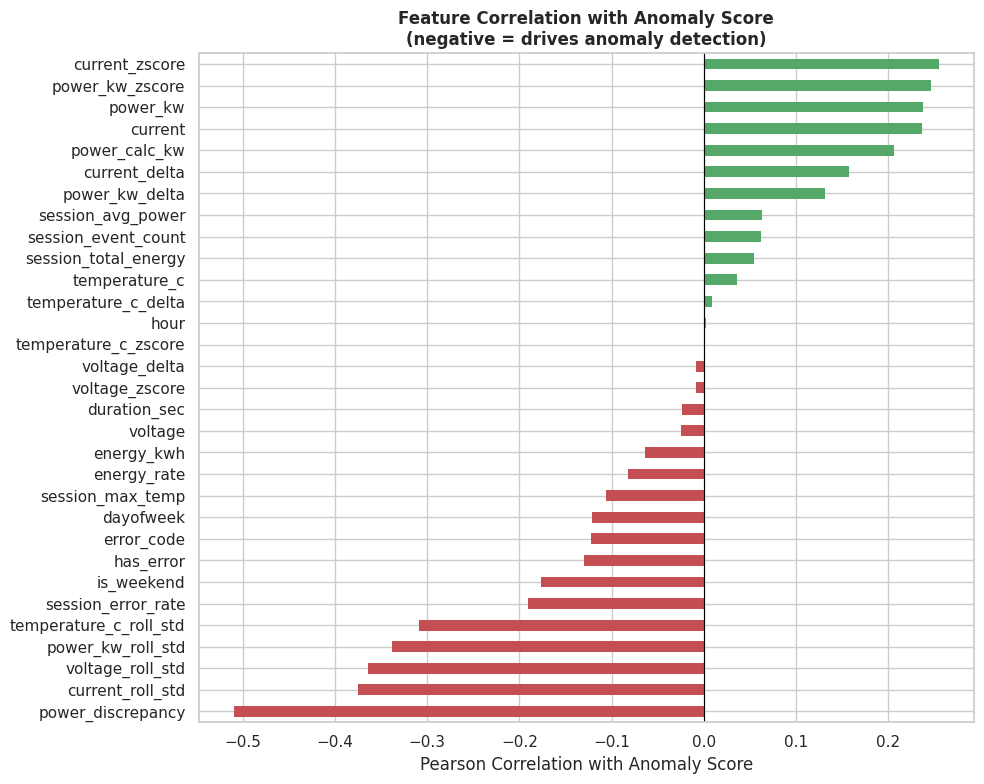

Top 5 features driving anomalies (most negative correlation):
power_discrepancy        -0.5100
current_roll_std         -0.3751
voltage_roll_std         -0.3640
power_kw_roll_std        -0.3384
temperature_c_roll_std   -0.3089
dtype: float64


In [22]:
# Approximate feature importance: correlation between each feature and anomaly score
# (lower score = more anomalous, so negative correlation = feature drives anomalies)
score_corr = X.corrwith(pd.Series(scores, name='anomaly_score')).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#C44E52' if v < 0 else '#55A868' for v in score_corr]
score_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Anomaly Score\n(negative = drives anomaly detection)',
             fontweight='bold')
ax.set_xlabel('Pearson Correlation with Anomaly Score')
plt.tight_layout()
plt.show()

print('Top 5 features driving anomalies (most negative correlation):')
print(score_corr.head(5))

### 5.5 Anomaly Breakdown by Trigger

Anomaly trigger breakdown:
  Model only (subtle, unknown patterns) :     617  (0.31%)
  Rules only (known fault signatures)   :   2,565  (1.29%)
  Both model + rules                    :   5,370  (2.69%)
  Total anomalous                        :   8,552  (4.29%)


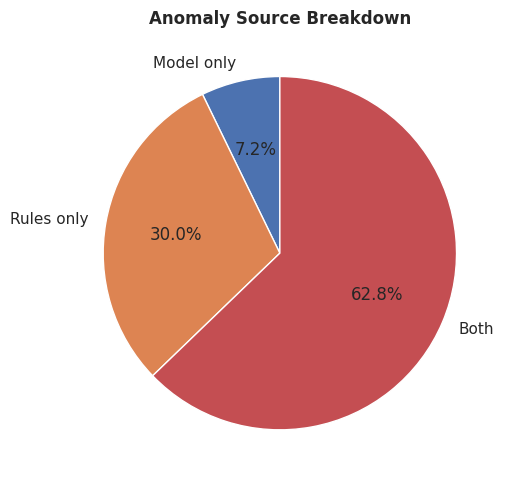

In [23]:
model_only = model_flags & ~rule_flags
rules_only = rule_flags & ~model_flags
both       = model_flags & rule_flags

print('Anomaly trigger breakdown:')
print(f'  Model only (subtle, unknown patterns) : {model_only.sum():>7,}  ({model_only.mean():.2%})')
print(f'  Rules only (known fault signatures)   : {rules_only.sum():>7,}  ({rules_only.mean():.2%})')
print(f'  Both model + rules                    : {both.sum():>7,}  ({both.mean():.2%})')
print(f'  Total anomalous                        : {is_anomaly.sum():>7,}  ({is_anomaly.mean():.2%})')

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Model only', 'Rules only', 'Both']
sizes  = [model_only.sum(), rules_only.sum(), both.sum()]
colors = ['#4C72B0', '#DD8452', '#C44E52']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Anomaly Source Breakdown', fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Analyze Model-only anomalies
df[model_only].describe()

,timestamp,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,power_calc_kw,power_discrepancy,has_error,energy_rate,hour,dayofweek,is_weekend,voltage_roll_mean,voltage_roll_std,voltage_delta,current_roll_mean,current_roll_std,current_delta,power_kw_roll_mean,power_kw_roll_std,power_kw_delta,temperature_c_roll_mean,temperature_c_roll_std,temperature_c_delta,session_error_rate,session_event_count,session_total_energy,session_avg_power,session_max_temp,voltage_mean,voltage_std,current_mean,current_std,power_kw_mean,power_kw_std,temperature_c_mean,temperature_c_std,voltage_zscore,current_zscore,power_kw_zscore,temperature_c_zscore,is_anomaly,anomaly_score
count,617,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000,617.0000
mean,2024-06-29 15:00:12.215559168,230.0273,31.6827,7.2924,44.8416,32.8233,0.0910,0.0000,7.2919,0.0503,0.0000,0.0027,11.4878,4.0259,0.5673,229.3858,17.0953,0.6416,29.0290,6.1391,2.6537,6.2410,2.3579,1.0514,45.2717,6.2784,-0.4301,0.0135,49.8282,3.1156,6.8915,62.0989,229.7176,11.6834,30.4931,3.1033,6.9720,1.1378,45.0869,3.8490,0.0249,0.3546,0.2630,-0.0641,1.0000,-0.5245
min,2024-01-03 14:36:49,215.0100,19.2400,4.3840,30.1900,1.0000,0.0014,0.0000,4.3544,0.0003,0.0000,0.0012,0.0000,0.0000,0.0000,191.9780,0.6364,-35.5180,19.6220,0.4473,-6.6320,1.1654,0.0681,-1.7166,27.1440,0.3576,-15.2540,0.0000,20.0000,0.9926,5.3915,37.8600,219.9721,10.5175,26.2224,2.7513,5.9089,0.9973,35.5414,3.5851,-0.9604,-2.7391,-1.8527,-1.7768,1.0000,-0.5947
25%,2024-03-31 06:05:18,225.0500,26.7300,6.0840,40.4100,13.0000,0.0276,0.0000,6.0958,0.0187,0.0000,0.0017,4.0000,3.0000,0.0000,223.6820,2.6331,-2.7060,26.3660,2.2656,-0.4540,4.6178,0.5262,0.0362,40.7500,1.6641,-2.8280,0.0000,32.0000,1.8680,6.2676,50.6700,226.3879,11.2003,27.3393,2.9366,6.3439,1.0683,41.8794,3.7543,-0.1708,-0.7335,-0.4460,-0.5052,1.0000,-0.5297
50%,2024-07-07 06:36:02,229.2400,32.8500,7.6020,46.1700,35.0000,0.0689,0.0000,7.6079,0.0389,0.0000,0.0022,12.0000,5.0000,1.0000,228.4040,3.6274,0.5480,28.2280,3.0387,3.0580,6.6620,0.7225,0.8276,46.5800,2.3860,-0.3440,0.0000,51.0000,3.1482,6.9838,55.2400,229.0565,11.9705,31.0897,3.0649,6.9810,1.1160,46.6520,3.8272,0.0381,0.6634,0.4587,-0.0484,1.0000,-0.5207
75%,2024-09-25 10:19:35,234.4200,36.2700,8.4020,49.5200,52.0000,0.1166,0.0000,8.3896,0.0727,0.0000,0.0024,19.0000,6.0000,1.0000,234.6140,37.4618,3.8840,32.5420,13.0380,5.8180,7.5754,5.6432,2.1276,49.7060,13.6521,1.9760,0.0253,67.0000,4.2776,7.5129,78.1000,233.6088,12.0974,32.8673,3.2248,7.5121,1.2182,49.0402,3.9324,0.2372,1.3610,0.9040,0.3968,1.0000,-0.5148
max,2024-12-30 19:08:06,252.3000,41.7000,9.6100,56.3700,60.0000,0.6979,0.0000,9.4903,0.1903,0.0000,0.0138,23.0000,6.0000,1.0000,272.4380,81.9062,36.4520,36.8340,16.6667,12.3020,8.5392,7.4789,5.8556,60.0440,25.0860,15.9980,0.0909,80.0000,6.2337,8.0457,93.9800,246.3550,12.4163,33.4889,3.4688,7.8092,1.2667,51.6878,4.1816,0.8437,3.3558,2.1188,1.7999,1.0000,-0.5107
std,NaN,7.0828,5.3957,1.2879,5.9734,20.0478,0.1055,0.0000,1.2825,0.0409,0.0000,0.0023,7.6999,2.0638,0.4959,13.5465,22.0757,12.8564,3.6682,5.5213,4.4773,1.5567,2.6393,1.4734,6.2665,6.5598,4.6043,0.0185,19.3732,1.3255,0.6978,15.5200,5.9706,0.5919,2.5637,0.2104,0.6223,0.0821,5.0304,0.1541,0.2987,1.2221,0.7904,0.6295,0.0000,0.0132


In [29]:
# Detection rate for firmware errors
error_mask = df['has_error'] == 1

total_error_events = error_mask.sum()
detected_error_events = (df.loc[error_mask, 'is_anomaly'] == 1).sum()

error_detection_rate = detected_error_events / total_error_events

print("=== Firmware Error Detection ===")
print(f"Total firmware error events     : {total_error_events:,}")
print(f"Detected as anomalies           : {detected_error_events:,}")
print(f"Detection rate                  : {error_detection_rate:.2%}")

=== Firmware Error Detection ===
Total firmware error events     : 1,109
Detected as anomalies           : 1,109
Detection rate                  : 100.00%


In [30]:
# Detection rate for high power discrepancy
disc_mask = df['power_discrepancy'] > 2.0

total_disc_events = disc_mask.sum()
detected_disc_events = (df.loc[disc_mask, 'is_anomaly'] == 1).sum()

disc_detection_rate = detected_disc_events / total_disc_events

print("\n=== Power Discrepancy Detection (> 2 kW) ===")
print(f"Total high-discrepancy events   : {total_disc_events:,}")
print(f"Detected as anomalies           : {detected_disc_events:,}")
print(f"Detection rate                  : {disc_detection_rate:.2%}")


=== Power Discrepancy Detection (> 2 kW) ===
Total high-discrepancy events   : 4,478
Detected as anomalies           : 4,478
Detection rate                  : 100.00%


In [31]:
# How many anomalies correspond to known patterns?
known_fault_mask = (
    (df['has_error'] == 1) |
    (df['power_discrepancy'] > 2.0) |
    (df['power_kw'] < 0)
)

total_anomalies = df['is_anomaly'].sum()
known_fault_anomalies = df.loc[known_fault_mask, 'is_anomaly'].sum()

print("\n=== Anomaly Explainability ===")
print(f"Total anomalies detected        : {total_anomalies:,}")
print(f"Anomalies matching known faults : {known_fault_anomalies:,}")
print(f"Fraction explained by rules     : {known_fault_anomalies / total_anomalies:.2%}")


=== Anomaly Explainability ===
Total anomalies detected        : 8,552
Anomalies matching known faults : 5,587
Fraction explained by rules     : 65.33%


In [32]:
# Detection rate by model alone (no rules)
model_error_detected = (model_flags & error_mask).sum()
model_disc_detected  = (model_flags & disc_mask).sum()

print("\n=== Model-Only Detection (No Rules) ===")
print(f"Firmware errors detected by model only : {model_error_detected / total_error_events:.2%}")
print(f"Power discrepancy >2 detected by model : {model_disc_detected / total_disc_events:.2%}")


=== Model-Only Detection (No Rules) ===
Firmware errors detected by model only : 15.51%
Power discrepancy >2 detected by model : 95.89%


## 6. Save Model & Export Results

In [24]:
# Save model
MODEL_PATH = 'model.joblib'
joblib.dump(model, MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

# Save anomaly summary
summary = df[df['is_anomaly'] == 1].sort_values('anomaly_score')[
    ['station_id', 'timestamp', 'session_id',
     'voltage', 'current', 'power_kw', 'temperature_c',
     'error_code', 'message', 'anomaly_score', 'is_anomaly']
]
summary.to_csv('anomaly_summary.csv', index=False)
print(f'Anomaly summary saved → anomaly_summary.csv ({len(summary):,} rows)')

# Save full predictions
df.to_csv('charging_logs_with_predictions.csv', index=False)
print(f'Full predictions saved → charging_logs_with_predictions.csv')

Model saved → model.joblib
Anomaly summary saved → anomaly_summary.csv (8,552 rows)
Full predictions saved → charging_logs_with_predictions.csv


In [25]:
# Download all outputs to your local machine
from google.colab import files
files.download('model.joblib')
files.download('anomaly_summary.csv')
files.download('charging_logs_with_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>